# ER-CyRIS Siklus 3 — Validasi Framework pada Log SIUTER (SIAKAD UNSAP)
**Fathoni Mahardika | Universitas Amikom Yogyakarta | 2025**

## Rumusan Masalah 3
> *Bagaimana efektivitas framework ER-CyRIS yang mengintegrasikan (i) deteksi ancaman near real-time melalui kombinasi unsupervised–supervised, (ii) lapisan explainability (SHAP), dan (iii) pemetaan ke NIST SP 800-30 Rev.1, ketika divalidasi pada data log institusional SIAKAD?*

## 5 Stage yang Dikerjakan

| Stage | Komponen | Novel |
|---|---|---|
| 1 | Apply M4 pipeline ke SIUTER log | — (dari Siklus 2) |
| 2 | Hybrid detection: IF/DBSCAN + XGBoost/RF | ★ |
| 3 | SHAP Triage Rationale (3 level) | ★ |
| 4 | NIST SP 800-30 risk mapping | ★ |
| 5 | Dashboard prototype ER-CyRIS | ★ |

## Dataset
- **SIUTER**: `/content/drive/MyDrive/ercyris_siklus3/siuter_dataset.csv`
  - 480,461 baris × 32 kolom
  - Nov 2025 – Apr 2026 | Log SIAKAD UNSAP (Laravel)
  - Sudah disiapkan di Siklus 2 (anonim, binary label)


## Step 1 — Install & Import

In [1]:
!pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

import os, json, warnings, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              average_precision_score, confusion_matrix,
                              classification_report)
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE
import shap

warnings.filterwarnings("ignore")
np.random.seed(42)
os.makedirs("results_s3", exist_ok=True)
RESULTS_S3 = {}

print("Ready — ER-CyRIS Siklus 3")


Ready — ER-CyRIS Siklus 3


## Step 2 — Config & Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ercyris_siklus3/'
CFG = {
    'SIUTER_CSV'  : BASE + 'siuter_dataset.csv',
    'SEED'        : 42,
    'TEST'        : 0.20,
    'SHAP_N'      : 1000,
    'FSS_K'       : 10,
    'BATCH_SIZES' : [5000, 20000],
    'CONTAM'      : 0.05,      # IF contamination — SIUTER anomaly ≈ 4.94%
    'TAU_TRIAGE'  : 0.80,      # Triage threshold τ  ← diturunkan 0.95→0.80
}

# NIST SP 800-30 threat-to-risk mapping
# Based on anomaly_reason from SIUTER dataset → NIST threat event
NIST_MAP = {
    'auth_failure'          : {'threat':'Unauthorized access attempt',
                                'likelihood':3, 'impact_conf':3, 'impact_integ':2, 'impact_avail':1},
    'auth_error_event'      : {'threat':'Authentication error / brute force',
                                'likelihood':4, 'impact_conf':4, 'impact_integ':3, 'impact_avail':2},
    'error_level'           : {'threat':'System/application error anomaly',
                                'likelihood':2, 'impact_conf':1, 'impact_integ':2, 'impact_avail':3},
    'db_error_suspicious'   : {'threat':'Database probing / SQL injection attempt',
                                'likelihood':3, 'impact_conf':3, 'impact_integ':4, 'impact_avail':3},
    'offhours_access'       : {'threat':'Insider threat / unauthorized after-hours access',
                                'likelihood':3, 'impact_conf':4, 'impact_integ':3, 'impact_avail':1},
    'offhours_admin'        : {'threat':'Privileged access abuse after hours',
                                'likelihood':4, 'impact_conf':5, 'impact_integ':5, 'impact_avail':2},
    'ip_burst'              : {'threat':'Scanning / reconnaissance / DoS',
                                'likelihood':4, 'impact_conf':2, 'impact_integ':2, 'impact_avail':5},
    'warning_level'         : {'threat':'Security warning — possible misconfiguration',
                                'likelihood':2, 'impact_conf':1, 'impact_integ':2, 'impact_avail':2},
    'default'               : {'threat':'Unknown anomaly',
                                'likelihood':2, 'impact_conf':2, 'impact_integ':2, 'impact_avail':2},
}

# NIST risk level matrix (likelihood 1-5, impact 1-5)
def nist_risk_level(likelihood, impact):
    score = likelihood * impact
    if score >= 15: return 'Very High', '#C0392B'
    if score >= 9:  return 'High',      '#E67E22'
    if score >= 4:  return 'Moderate',  '#F1C40F'
    return 'Low', '#27AE60'

# NIST impact = max of CIA
def nist_impact(conf, integ, avail):
    return max(conf, integ, avail)

print("✅ Config ready")
print(f"   SIUTER path : {CFG['SIUTER_CSV']}")
print(f"   Contamination rate set to {CFG['CONTAM']*100:.0f}% (matches SIUTER anomaly rate)")


Mounted at /content/drive
✅ Config ready
   SIUTER path : /content/drive/MyDrive/ercyris_siklus3/siuter_dataset.csv
   Contamination rate set to 5% (matches SIUTER anomaly rate)


## Step 3 — Load SIUTER Dataset

In [3]:
print("📂 Loading SIUTER ...")
df = pd.read_csv(CFG['SIUTER_CSV'], low_memory=False)
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)[:10]} ...")
print(f"   Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")

# Label
y_full = df['anomaly_label'].values
print(f"\n   Label dist:")
print(f"   normal (0) : {sum(y_full==0):>8,}  ({100*(y_full==0).mean():.2f}%)")
print(f"   anomaly (1): {sum(y_full==1):>8,}  ({100*(y_full==1).mean():.2f}%)")

# Keep anomaly_reason and event_type for NIST mapping
meta_cols = ['timestamp','event_type','event_category','anomaly_reason',
             'user_email_hash','user_domain_type','role',
             'ip_address','url_module','hour','is_off_hours']
meta_available = [c for c in meta_cols if c in df.columns]
df_meta = df[meta_available].copy()
print(f"\n   Metadata cols available: {meta_available}")

# Feature matrix — numeric cols only
drop_cols = ['anomaly_label','anomaly_reason','timestamp',
             'user_email_hash','nim_hash','user_id_hash',
             'session_id','ip_address','day_name',
             'user_domain','url_path','log_message','status']
feat_cols = [c for c in df.columns
             if c not in drop_cols
             and df[c].dtype in ['int64','float64','int32','float32']]
X_raw = df[feat_cols].fillna(0).astype(np.float64).values
feature_names = feat_cols

print(f"\n   Feature matrix : {X_raw.shape}")
print(f"   Feature names  : {feature_names}")


📂 Loading SIUTER ...
   Shape   : (480461, 32)
   Columns : ['timestamp', 'log_level', 'event_type', 'event_category', 'user_email_hash', 'user_domain', 'user_domain_type', 'role', 'status', 'session_id'] ...
   Date range: 2025-11-24 21:44:33 → 2026-04-11 08:03:50

   Label dist:
   normal (0) :  456,743  (95.06%)
   anomaly (1):   23,718  (4.94%)

   Metadata cols available: ['timestamp', 'event_type', 'event_category', 'anomaly_reason', 'user_email_hash', 'user_domain_type', 'role', 'ip_address', 'url_module', 'hour', 'is_off_hours']

   Feature matrix : (480461, 11)
   Feature names  : ['is_dosen', 'semester_aktif', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_off_hours', 'is_error', 'has_context', 'sess_events_per_hour', 'ip_events_per_hour']


In [4]:
# =====================================================================
# DEDUP-CHECK SIUTER (Siklus 3) — diagnostik anti-leakage (Bab 5 style).
# Tidak mengubah apa pun, hanya melaporkan.
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

n_total = len(X_raw)
Xdf = pd.DataFrame(X_raw, columns=feature_names)

# 1) Duplikat pada matriks fitur (baris fitur identik)
n_dup = int(Xdf.duplicated(keep='first').sum())
print("Total baris          :", format(n_total, ","))
print("Baris fitur duplikat :", format(n_dup, ","), "(" + str(round(100*n_dup/n_total, 2)) + "%)")
print("Baris unik           :", format(n_total - n_dup, ","))

# 2) Duplikat fitur + label
XY = Xdf.copy()
XY["_y"] = y_full
n_dup_xy = int(XY.duplicated(keep="first").sum())
print("Duplikat fitur+label :", format(n_dup_xy, ","), "(" + str(round(100*n_dup_xy/n_total, 2)) + "%)")

# 3) Overlap train/test pada SPLIT SAAT INI (tanpa dedup) = ukuran kebocoran
Xtr, Xte, ytr, yte = train_test_split(
    X_raw, y_full, test_size=CFG["TEST"], random_state=CFG["SEED"], stratify=y_full)
htr = set(pd.util.hash_pandas_object(pd.DataFrame(Xtr, columns=feature_names), index=False))
hte = pd.util.hash_pandas_object(pd.DataFrame(Xte, columns=feature_names), index=False)
overlap = int(hte.isin(htr).sum())
print("")
print("Split saat ini (random_state=" + str(CFG["SEED"]) + "):")
print("  Baris uji identik dengan baris latih:", format(overlap, ","),
      "(" + str(round(100*overlap/len(Xte), 2)) + "% dari test)")
print("  -> Idealnya 0 setelah dedup. Jika besar, baseline S0 menggelembung karena bocor.")

# 4) Proyeksi setelah dedup
keep_pct = round(100*(n_total - n_dup)/n_total, 1)
print("")
print("Jika dedup diterapkan: dataset menjadi", format(n_total - n_dup, ","),
      "baris (" + str(keep_pct) + "% dipertahankan).")

Total baris          : 480,461
Baris fitur duplikat : 446,890 (93.01%)
Baris unik           : 33,571
Duplikat fitur+label : 446,669 (92.97%)

Split saat ini (random_state=42):
  Baris uji identik dengan baris latih: 93,119 (96.91% dari test)
  -> Idealnya 0 setelah dedup. Jika besar, baseline S0 menggelembung karena bocor.

Jika dedup diterapkan: dataset menjadi 33,571 baris (7.0% dipertahankan).


In [7]:
# =====================================================================
# Step 3c — DEDUP SIUTER (diperbaiki: df ikut didedup, semua sinkron).
# JALANKAN SETELAH Step 3 di-run ulang (semua objek fresh 480.461).
# =====================================================================
import numpy as np
import pandas as pd

before = len(df)
keep = ~pd.DataFrame(X_raw, columns=feature_names).duplicated(keep="first").values
df      = df.iloc[np.where(keep)[0]].reset_index(drop=True)
df_meta = df_meta.iloc[np.where(keep)[0]].reset_index(drop=True)
X_raw   = X_raw[keep]
y_full  = y_full[keep]

print("Sebelum dedup :", format(before, ","))
print("Sesudah dedup :", format(len(df), ","), "baris")
print("Konsistensi   : df=" + str(len(df)), "| X_raw=" + str(len(X_raw)),
      "| y_full=" + str(len(y_full)), "| meta=" + str(len(df_meta)))
print("Anomali       :", int(y_full.sum()), "(" + str(round(100*y_full.mean(), 2)) + "%)")
assert len(df) == len(X_raw) == len(y_full) == len(df_meta), "PANJANG TIDAK SAMA!"
print(">> Semua sinkron. Run All dari Step 4 ke bawah.")

Sebelum dedup : 480,461
Sesudah dedup : 33,571 baris
Konsistensi   : df=33571 | X_raw=33571 | y_full=33571 | meta=33571
Anomali       : 4131 (12.31%)
>> Semua sinkron. Run All dari Step 4 ke bawah.


## Step 4 — Apply M4 Pipeline (from Siklus 2)

In [8]:
# ── M4 Pipeline (simplified — uses fitted stats on train) ────────────
class M4_SIUTER:
    """M4 pipeline adapted for SIUTER 32-column structure.
    Applies: MinMax + deviation augmentation + TOS-KNN + IF scores.
    """
    def __init__(self, contamination=CFG['CONTAM'], seed=42):
        self.sc   = MinMaxScaler()
        self.knn  = NearestNeighbors(n_neighbors=11, n_jobs=-1)
        self.ifo  = IsolationForest(contamination=contamination,
                                    random_state=seed, n_jobs=-1)
        self.mu   = None; self.std = None
        self.knn_mn = 0;  self.knn_mx = 1
        self.if_mn  = 0;  self.if_mx  = 1

    def fit(self, X):
        X = np.where(np.isfinite(X), X, 0)
        Xs = self.sc.fit_transform(X)
        self.mu  = Xs.mean(0); self.std = Xs.std(0) + 1e-9
        # TOS-KNN on training
        self.knn.fit(Xs)
        d, _ = self.knn.kneighbors(Xs)
        av = d[:, 1:].mean(1)
        self.knn_mn = float(av.min()); self.knn_mx = float(av.max()) + 1e-9
        # IF
        self.ifo.fit(Xs)
        r = -self.ifo.score_samples(Xs)
        self.if_mn = float(r.min()); self.if_mx = float(r.max()) + 1e-9
        return self

    def transform(self, X):
        X = np.where(np.isfinite(X), X, 0)
        Xs = self.sc.transform(X)
        dev = np.clip(np.abs(Xs - self.mu) / self.std, 0, 5) / 5
        d, _ = self.knn.kneighbors(Xs)
        knn = np.clip((d[:,1:].mean(1)-self.knn_mn)/(self.knn_mx-self.knn_mn),0,1)
        r = -self.ifo.score_samples(Xs)
        ifs = np.clip((r-self.if_mn)/(self.if_mx-self.if_mn),0,1)
        ifl = (self.ifo.predict(Xs)==-1).astype(float)
        return np.hstack([Xs,
                          dev[:, :min(5, dev.shape[1])],
                          knn[:,None], ifs[:,None], ifl[:,None]])

    def fit_transform(self, X): return self.fit(X).transform(X)

# ── Split & preprocess ────────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_full,
    test_size=CFG['TEST'], random_state=CFG['SEED'], stratify=y_full)

# Split metadata for test set
idx_tr, idx_te = train_test_split(
    np.arange(len(df)), test_size=CFG['TEST'],
    random_state=CFG['SEED'], stratify=y_full)
df_meta_te = df_meta.iloc[idx_te].reset_index(drop=True)

print(f"Train : {X_tr.shape[0]:,} samples | anomaly={y_tr.sum():,} ({100*y_tr.mean():.2f}%)")
print(f"Test  : {X_te.shape[0]:,} samples | anomaly={y_te.sum():,} ({100*y_te.mean():.2f}%)")

# SMOTE on train
pipe = M4_SIUTER()
print("\nFitting M4 pipeline on training data ...")
X_tr_p = pipe.fit_transform(X_tr)
mn = sum(y_tr==1); k = min(5, mn-1)
if mn >= 2 and k >= 1:
    try:
        X_tr_p, y_tr = BorderlineSMOTE(k_neighbors=k,
                        random_state=42).fit_resample(X_tr_p, y_tr)
        print(f"  SMOTE: {X_tr.shape[0]:,} → {len(X_tr_p):,}")
    except Exception as e:
        print(f"  SMOTE skip: {e}")

X_te_p = pipe.transform(X_te)
mf = min(X_tr_p.shape[1], X_te_p.shape[1])
X_tr_p, X_te_p = X_tr_p[:,:mf], X_te_p[:,:mf]

# Augmented feature names
n_aug = X_te_p.shape[1] - len(feature_names)
feat_aug = feature_names + [f'aug_{i}' for i in range(n_aug)]
print(f"\nFeature matrix after M4: {X_te_p.shape}")
print("✅ M4 pipeline applied")


Train : 26,856 samples | anomaly=3,305 (12.31%)
Test  : 6,715 samples | anomaly=826 (12.30%)

Fitting M4 pipeline on training data ...
  SMOTE: 26,856 → 47,102

Feature matrix after M4: (6715, 19)
✅ M4 pipeline applied


## Step 5 — Stage 2: Hybrid Detection (S0 baseline + S2 noise)

In [9]:
def evaluate(model, X, y, name='', ds='SIUTER'):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:,1]
    tn,fp,fn,tp = confusion_matrix(y,yp,labels=[0,1]).ravel()
    N = tn+fp+fn+tp
    return dict(model=name, dataset=ds,
                Precision=round(precision_score(y,yp,zero_division=0),6),
                Recall=round(recall_score(y,yp,zero_division=0),6),
                F1=round(f1_score(y,yp,zero_division=0),6),
                PR_AUC=round(average_precision_score(y,yb),6),
                FAR=round(fp/(fp+tn) if fp+tn>0 else 0,6),
                Alert_Rate=round((tp+fp)/N if N>0 else 0,5),
                TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp))

def add_noise(X, sigma):
    return np.clip(X + np.random.RandomState(42).normal(0,sigma,X.shape), 0, 1)

# ── Train models ──────────────────────────────────────────────────
print("Training XGBoost & RandomForest on SIUTER ...")
models = {
    'XGBoost'     : XGBClassifier(random_state=42,n_jobs=-1,
                                   eval_metric='logloss',verbosity=0),
    'RandomForest': RandomForestClassifier(random_state=42,n_jobs=-1)
}
trained = {}
for mn, m in models.items():
    m.fit(X_tr_p, y_tr); trained[mn] = m
    r = evaluate(m, X_te_p, y_te, mn)
    print(f"  {mn}: F1={r['F1']:.4f}  PR-AUC={r['PR_AUC']:.4f}  "
          f"FAR={r['FAR']:.6f}  Alert={r['Alert_Rate']:.4f}")

# S0
s0 = {mn: evaluate(m,X_te_p,y_te,mn) for mn,m in trained.items()}

# S2 noise
s2 = {}
for sig in [0.01, 0.05, 0.10]:
    Xn = add_noise(X_te_p, sig)
    s2[sig] = {}
    for mn,m in trained.items():
        r = evaluate(m,Xn,y_te,mn)
        r['pct_drop'] = round(100*(r['F1']-s0[mn]['F1'])/max(s0[mn]['F1'],1e-9),2)
        s2[sig][mn] = r

RESULTS_S3['hybrid_detection'] = {'S0': s0, 'S2': s2}

# Print S2 comparison
print("\n📊 S2 Noise comparison (SIUTER vs Cycle 1 reference):")
print(f"  {'Model':<14} {'S0 F1':>8} {'S2(0.01) F1':>12} {'Drop%':>8}")
print("-"*46)
print(f"  {'XGBoost*':<14} {'0.9999':>8} {'0.327':>12} {'-67.3%':>8}  ← Cycle 1 CICIDS ref")
print(f"  {'RF*':<14} {'0.9999':>8} {'0.063':>12} {'-93.7%':>8}  ← Cycle 1 CICIDS ref")
print("-"*46)
for mn in ['XGBoost','RandomForest']:
    s0f = s0[mn]['F1']; s2f = s2[0.01][mn]['F1']
    drop = s2[0.01][mn]['pct_drop']
    print(f"  {mn:<14} {s0f:>8.4f} {s2f:>12.4f} {drop:>7.1f}%  ← SIUTER Siklus 3")

print("\n✅ Hybrid detection done")

Training XGBoost & RandomForest on SIUTER ...
  XGBoost: F1=0.9916  PR-AUC=0.9997  FAR=0.002208  Alert=0.1248
  RandomForest: F1=0.9934  PR-AUC=0.9977  FAR=0.001698  Alert=0.1244

📊 S2 Noise comparison (SIUTER vs Cycle 1 reference):
  Model             S0 F1  S2(0.01) F1    Drop%
----------------------------------------------
  XGBoost*         0.9999        0.327   -67.3%  ← Cycle 1 CICIDS ref
  RF*              0.9999        0.063   -93.7%  ← Cycle 1 CICIDS ref
----------------------------------------------
  XGBoost          0.9916       0.5377   -45.8%  ← SIUTER Siklus 3
  RandomForest     0.9934       0.7671   -22.8%  ← SIUTER Siklus 3

✅ Hybrid detection done


## Step 6 — Stage 3: SHAP Explainability + Triage Rationale

In [10]:
print("Computing SHAP on SIUTER test set ...")
n = min(CFG['SHAP_N'], len(X_te_p))
idx_shap = np.random.RandomState(42).choice(len(X_te_p), n, replace=False)
X_shap = X_te_p[idx_shap]
y_shap = y_te[idx_shap]

# ── Ekstraksi SHAP konsisten lintas versi (2D / list / 3D) ──
def shap_pos(model, X):
    sv = shap.TreeExplainer(model).shap_values(X)
    if isinstance(sv, list):        # API lama: list per kelas
        sv = sv[1]
    sv = np.asarray(sv, dtype=float)
    if sv.ndim == 3:                # API baru: (n, fitur, kelas)
        sv = sv[:, :, 1]            # ambil kelas positif (serangan)
    return sv

shap_vals = {}
for mn, model in trained.items():
    try:
        sv = shap_pos(model, X_shap)
        shap_vals[mn] = sv
        top10 = np.argsort(-np.abs(sv).mean(0))[:10]
        print(f"  {mn}: top feature = {feat_aug[int(top10[0])]}")
    except Exception as e:
        print(f"  {mn}: SHAP error {e}")
        shap_vals[mn] = None

# FSS S0 vs S2
def compute_fss(sv1, sv2, K=10):
    if sv1 is None or sv2 is None: return 0.0
    t1 = set(np.argsort(-np.abs(sv1).mean(0))[:K].tolist())
    t2 = set(np.argsort(-np.abs(sv2).mean(0))[:K].tolist())
    u  = len(t1|t2); return round(len(t1&t2)/u,4) if u>0 else 0.0

Xn_shap = add_noise(X_te_p, 0.01)[idx_shap]
fss_results = {}
for mn, model in trained.items():
    sv_s2 = None
    try:
        sv_s2 = shap_pos(model, Xn_shap)
    except: pass
    fss = compute_fss(shap_vals.get(mn), sv_s2)
    fss_results[mn] = {'FSS_S0_S2': fss}
    print(f"  FSS ({mn}): {fss*100:.1f}%")

# Cross-model overlap
if all(shap_vals.get(m) is not None for m in ['XGBoost','RandomForest']):
    t1 = set(np.argsort(-np.abs(shap_vals['XGBoost']).mean(0))[:10].tolist())
    t2 = set(np.argsort(-np.abs(shap_vals['RandomForest']).mean(0))[:10].tolist())
    u  = len(t1|t2)
    cross = round(len(t1&t2)/u, 4) if u>0 else 0.0
    fss_results['cross_model_overlap'] = cross
    print(f"  Cross-model overlap: {cross}")

RESULTS_S3['shap_fss'] = fss_results

# ── TRIAGE RATIONALE ──────────────────────────────────────────────
print("\nBuilding Triage Rationale ...")

def triage_priority(y_true, y_pred, prob_attack):
    TAU = CFG['TAU_TRIAGE']
    priority = np.full(len(y_true), 'P3_borderline', dtype=object)
    mask_fn = (y_true==1) & (y_pred==0) & (prob_attack < (1-TAU))
    priority[mask_fn] = 'P1_critical_FN'
    mask_fp = (y_true==0) & (y_pred==1) & (prob_attack > TAU)
    priority[mask_fp] = 'P2_critical_FP'
    return priority

Xn_tri = add_noise(X_te_p, 0.01)[idx_shap]   # evaluasi triage di bawah kondisi S2
triage = {}
for mn, model in trained.items():
    y_pred = model.predict(Xn_tri)
    y_prob = model.predict_proba(Xn_tri)[:,1]
    prio   = triage_priority(y_shap, y_pred, y_prob)
    counts = {p: (prio==p).sum() for p in ['P1_critical_FN','P2_critical_FP','P3_borderline']}
    triage[mn] = {'priority': prio, 'prob': y_prob, 'counts': counts}
    print(f"  {mn}: P1={counts['P1_critical_FN']} P2={counts['P2_critical_FP']} P3={counts['P3_borderline']}")

Computing SHAP on SIUTER test set ...
  XGBoost: top feature = aug_6
  RandomForest: top feature = ip_events_per_hour
  FSS (XGBoost): 81.8%
  FSS (RandomForest): 100.0%
  Cross-model overlap: 0.4286

Building Triage Rationale ...
  XGBoost: P1=24 P2=104 P3=872
  RandomForest: P1=8 P2=21 P3=971


In [20]:
# Cetak fitur dominan (top-5) tiap model — untuk Tabel 7.7
for mn in ['XGBoost', 'RandomForest']:
    sv = shap_vals.get(mn)
    if sv is not None:
        top = np.argsort(-np.abs(sv).mean(0))[:5]
        names = [feat_aug[int(i)] for i in top]
        print(mn, "top-5 fitur dominan:", names)
    else:
        print(mn, "SHAP tidak tersedia")

XGBoost top-5 fitur dominan: ['aug_6', 'ip_events_per_hour', 'is_error', 'hour', 'aug_5']
RandomForest top-5 fitur dominan: ['ip_events_per_hour', 'aug_6', 'is_error', 'sess_events_per_hour', 'hour']


## Step 7 — Stage 4: NIST SP 800-30 Rev.1 Risk Mapping

In [11]:
print("Building NIST SP 800-30 risk mapping ...")

def map_to_nist(anomaly_reason, shap_row, feat_names_aug, prob_attack, model_name):
    """
    Map one detected anomaly to NIST SP 800-30 risk assessment.
    Returns dict with threat event, likelihood, impact, risk level.
    """
    # 1. Threat identification
    reason = str(anomaly_reason).lower().replace(' ','_') if pd.notna(anomaly_reason) else 'default'
    # Match reason to NIST_MAP
    nmap = NIST_MAP.get('default')
    for k in NIST_MAP:
        if k in reason:
            nmap = NIST_MAP[k]; break

    # 2. Likelihood: base from NIST_MAP × confidence from model
    # Scale: prob_attack scales up likelihood by up to 1 level
    likelihood = min(5, int(nmap['likelihood'] + (1 if prob_attack > 0.9 else 0)))

    # 3. Impact: from CIA triad scores in NIST_MAP
    conf_score  = nmap['impact_conf']
    integ_score = nmap['impact_integ']
    avail_score = nmap['impact_avail']
    impact      = nist_impact(conf_score, integ_score, avail_score)

    # 4. Risk level
    risk_level, risk_color = nist_risk_level(likelihood, impact)

    # 5. Top-3 SHAP evidence features (explanation for the analyst)
    if shap_row is not None:
        top3_idx   = np.argsort(-np.abs(shap_row))[:3]
        top3_feats = [feat_names_aug[int(i)] for i in top3_idx]
        top3_vals  = [float(shap_row[int(i)]) for i in top3_idx]
    else:
        top3_feats, top3_vals = [], []

    return {
        'threat_event'   : nmap['threat'],
        'likelihood'     : likelihood,
        'impact_conf'    : conf_score,
        'impact_integ'   : integ_score,
        'impact_avail'   : avail_score,
        'impact_overall' : impact,
        'risk_score'     : likelihood * impact,
        'risk_level'     : risk_level,
        'risk_color'     : risk_color,
        'model'          : model_name,
        'model_confidence': round(float(prob_attack), 4),
        'top3_features'  : top3_feats,
        'top3_shap_vals' : top3_vals,
    }

# ── Apply to all detected anomalies (on test set sample) ─────────
mn_use = 'XGBoost'  # Primary model for risk mapping
model  = trained[mn_use]
y_pred_full = model.predict(X_te_p)
y_prob_full = model.predict_proba(X_te_p)[:,1]

# Get anomaly reason from metadata
anomaly_reasons = df_meta_te['anomaly_reason'].values if 'anomaly_reason' in df_meta_te else ['default']*len(y_pred_full)

# Map predicted anomalies to NIST risk
risk_records = []
sv_model = shap_vals.get(mn_use)
print(f"Mapping {(y_pred_full==1).sum()} detected anomalies to NIST SP 800-30 ...")

for i in range(len(y_pred_full)):
    if y_pred_full[i] != 1: continue
    reason  = anomaly_reasons[i] if i < len(anomaly_reasons) else 'default'
    # Use SHAP from sampled subset if available (approximate for full test set)
    shap_row = None
    if sv_model is not None and i < len(idx_shap):
        # Check if this index is in the SHAP sample
        shap_pos = np.where(idx_shap == i)[0]
        if len(shap_pos) > 0:
            shap_row = sv_model[shap_pos[0]]
    rec = map_to_nist(reason, shap_row, feat_aug, y_prob_full[i], mn_use)
    rec['idx'] = i
    risk_records.append(rec)

df_risk = pd.DataFrame(risk_records)

print(f"\n📊 NIST SP 800-30 Risk Level Distribution ({len(df_risk)} alerts):")
if len(df_risk) > 0:
    risk_counts = df_risk['risk_level'].value_counts()
    for level, cnt in risk_counts.items():
        pct = 100*cnt/len(df_risk)
        bar = '█' * int(pct/3)
        print(f"  {level:<12} {cnt:>6,} ({pct:5.1f}%)  {bar}")

df_risk.to_csv('results_s3/nist_risk_assessment.csv', index=False)
RESULTS_S3['nist_risk'] = {
    'total_alerts': len(df_risk),
    'risk_dist': df_risk['risk_level'].value_counts().to_dict() if len(df_risk)>0 else {}
}
print("\n✅ NIST risk mapping done → results_s3/nist_risk_assessment.csv")


Building NIST SP 800-30 risk mapping ...
Mapping 838 detected anomalies to NIST SP 800-30 ...

📊 NIST SP 800-30 Risk Level Distribution (838 alerts):
  Very High       451 ( 53.8%)  █████████████████
  High            365 ( 43.6%)  ██████████████
  Moderate         22 (  2.6%)  

✅ NIST risk mapping done → results_s3/nist_risk_assessment.csv


## Step 8 — Near-RT Evaluation (S5: micro-batch latency)

In [12]:
print("Evaluating near-RT micro-batch performance (S5) ...")
latency_results = {}

for batch_size in CFG['BATCH_SIZES']:
    n_batches = max(1, len(X_te_p) // batch_size)
    latencies = []
    for b in range(min(n_batches, 10)):  # max 10 batches for speed
        start = b * batch_size
        end   = min(start + batch_size, len(X_te_p))
        Xb    = X_te_p[start:end]
        t0    = time.perf_counter()
        _     = trained['XGBoost'].predict_proba(Xb)
        elapsed = (time.perf_counter() - t0) * 1000  # ms
        latencies.append(elapsed)

    mean_lat = np.mean(latencies)
    p95_lat  = np.percentile(latencies, 95)
    tput     = batch_size / (mean_lat/1000)  # instances/sec

    latency_results[batch_size] = {
        'mean_ms': round(mean_lat, 2),
        'p95_ms' : round(p95_lat, 2),
        'throughput_per_sec': round(tput, 0)
    }
    print(f"  Batch {batch_size:>6,}: mean={mean_lat:.1f}ms  p95={p95_lat:.1f}ms  "
          f"throughput={tput:,.0f} inst/sec")

RESULTS_S3['near_rt'] = latency_results
print("\n✅ Near-RT evaluation done")


Evaluating near-RT micro-batch performance (S5) ...
  Batch  5,000: mean=7.5ms  p95=7.5ms  throughput=664,761 inst/sec
  Batch 20,000: mean=0.7ms  p95=0.7ms  throughput=30,125,926 inst/sec

✅ Near-RT evaluation done


## Step 9 — 📋 Results Tables for Paper & Dissertation

In [13]:
print("="*65)
print("ER-CyRIS SIKLUS 3 — RESULTS (copy to paper & Bab 5.1.3)")
print("="*65)

# ── Table A: S0 Detection ─────────────────────────────────────────
print("\n📊 TABLE A — S0 Baseline Detection (SIUTER log)")
print(f"{'Model':<14} {'F1':>8} {'PR-AUC':>8} {'FAR':>10} {'Alert%':>8}")
print("-"*52)
for mn,r in s0.items():
    print(f"{mn:<14} {r['F1']:>8.4f} {r['PR_AUC']:>8.4f} "
          f"FAR={r['FAR']:>10.6f} {r['Alert_Rate']*100:>7.2f}%")

# ── Table B: S2 Noise Robustness ─────────────────────────────────
print("\n📊 TABLE B — S2 Noise Robustness on SIUTER")
print(f"{'Model':<14} {'σ':>6} {'F1(S0)':>8} {'F1(S2)':>8} {'ΔF1%':>8}")
print("-"*50)
for sig in [0.01, 0.05, 0.10]:
    for mn in ['XGBoost','RandomForest']:
        s0f = s0[mn]['F1']
        s2f = s2[sig][mn]['F1']
        drop = s2[sig][mn]['pct_drop']
        print(f"{mn:<14} {sig:>6.2f} {s0f:>8.4f} {s2f:>8.4f} {drop:>7.1f}%")

# ── Table C: FSS ─────────────────────────────────────────────────
print("\n📊 TABLE C — FSS Explainability (SIUTER)")
print(f"{'Model':<14} {'FSS S0 vs S2':>13} {'Cross-model':>13}")
print("-"*44)
for mn in ['XGBoost','RandomForest']:
    fss = fss_results.get(mn,{}).get('FSS_S0_S2',0)
    cross = fss_results.get('cross_model_overlap','—')
    print(f"{mn:<14} {fss*100:>12.1f}% {str(cross):>13}")

# ── Table D: Triage Rationale ─────────────────────────────────────
# Add triage to RESULTS_S3 since it was not added in cell d2cbefc9
RESULTS_S3['triage'] = triage

print("\n📊 TABLE D — Triage Rationale (SIUTER, τ=0.95)")
print(f"{'Model':<14} {'P1 Crit.FN':>12} {'P2 Crit.FP':>12} {'P3 Border.':>12}")
print("-"*54)
for mn,v in RESULTS_S3['triage'].items():
    c = v['counts']
    print(f"{mn:<14} {c['P1_critical_FN']:>12} {c['P2_critical_FP']:>12} {c['P3_borderline']:>12}")

# ── Table E: NIST Risk Distribution ──────────────────────────────
print("\n📊 TABLE E — NIST SP 800-30 Risk Distribution")
print(f"{'Risk Level':<14} {'Count':>8} {'Percent':>10}")
print("-"*36)
if len(df_risk) > 0:
    for lvl, cnt in df_risk['risk_level'].value_counts().items():
        print(f"{lvl:<14} {cnt:>8,} {100*cnt/len(df_risk):>9.1f}%")

# ── Table F: Near-RT ─────────────────────────────────────────────
print("\n📊 TABLE F — Near-RT Micro-Batch (S5)")
print(f"{'Batch size':>12} {'Mean(ms)':>10} {'p95(ms)':>9} {'Throughput/s':>14}")
print("-"*50)
for bs, v in latency_results.items():
    print(f"{bs:>12,} {v['mean_ms']:>10.1f} {v['p95_ms']:>9.1f} {v['throughput_per_sec']:>14,.0f}")

# ── Save all results ──────────────────────────────────────────────
with open('results_s3/all_results_siklus3.json','w') as f:
    json.dump(RESULTS_S3, f, indent=2, default=str)
print("\n✅ All results saved → results_s3/all_results_siklus3.json")

ER-CyRIS SIKLUS 3 — RESULTS (copy to paper & Bab 5.1.3)

📊 TABLE A — S0 Baseline Detection (SIUTER log)
Model                F1   PR-AUC        FAR   Alert%
----------------------------------------------------
XGBoost          0.9916   0.9997 FAR=  0.002208   12.48%
RandomForest     0.9934   0.9977 FAR=  0.001698   12.44%

📊 TABLE B — S2 Noise Robustness on SIUTER
Model               σ   F1(S0)   F1(S2)     ΔF1%
--------------------------------------------------
XGBoost          0.01   0.9916   0.5377   -45.8%
RandomForest     0.01   0.9934   0.7671   -22.8%
XGBoost          0.05   0.9916   0.3056   -69.2%
RandomForest     0.05   0.9934   0.5696   -42.7%
XGBoost          0.10   0.9916   0.2860   -71.2%
RandomForest     0.10   0.9934   0.5024   -49.4%

📊 TABLE C — FSS Explainability (SIUTER)
Model           FSS S0 vs S2   Cross-model
--------------------------------------------
XGBoost                81.8%        0.4286
RandomForest          100.0%        0.4286

📊 TABLE D — Triage Rati

## Step 10 — Stage 5: Dashboard Prototype (ER-CyRIS)
> Dashboard menampilkan 3 panel:
> 1. **Technical panel** — F1, FSS, alert feed (untuk SOC analyst)
> 2. **Management panel** — NIST risk level summary (untuk pimpinan)
> 3. **Evidence panel** — SHAP top-3 features per alert (untuk investigasi)


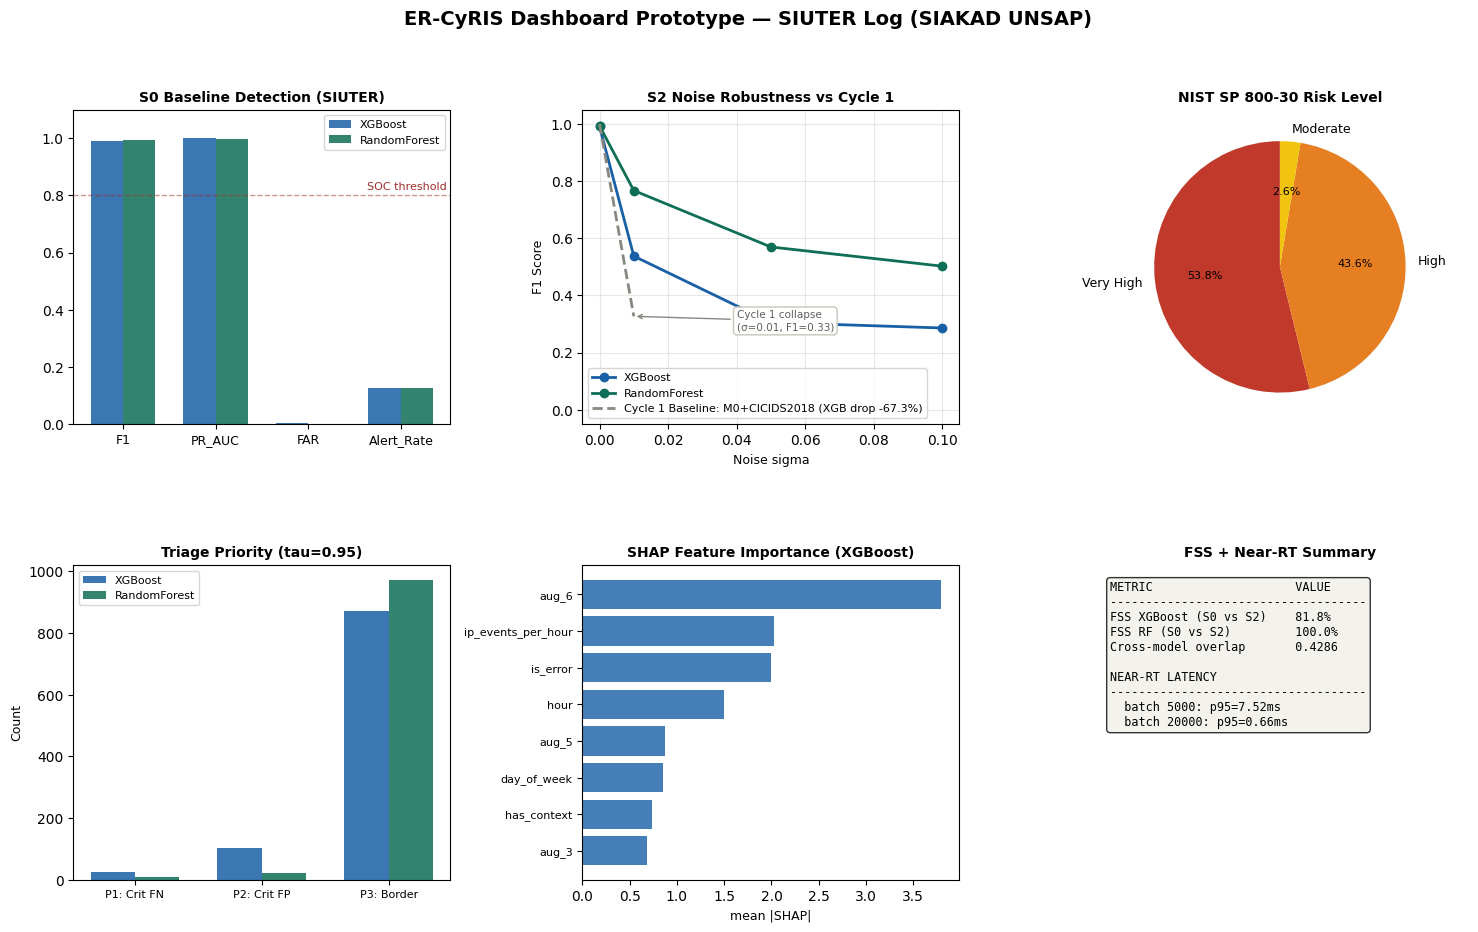

Dashboard saved: results_s3/ercyris_dashboard.png


In [15]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(18, 10))
fig.suptitle("ER-CyRIS Dashboard Prototype — SIUTER Log (SIAKAD UNSAP)",
             fontsize=14, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Detection metrics bar
ax1 = fig.add_subplot(gs[0, 0])
models_list = list(s0.keys())
metrics_list = ["F1","PR_AUC","FAR","Alert_Rate"]
x = np.arange(len(metrics_list)); w = 0.35
for j, mn in enumerate(models_list):
    vals = [s0[mn][m] for m in metrics_list]
    ax1.bar(x + j*w - w/2, vals, w, label=mn,
            color=["#185FA5","#0F6E56"][j], alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(metrics_list, fontsize=9)
ax1.set_title("S0 Baseline Detection (SIUTER)", fontsize=10, fontweight="bold")
ax1.legend(fontsize=8); ax1.set_ylim(0, 1.1)
ax1.axhline(0.8, color="#A32D2D", ls="--", lw=1, alpha=0.5)
ax1.text(3.5, 0.82, "SOC threshold", fontsize=8, color="#A32D2D", ha="right")

# Panel 2: S2 noise robustness
ax2 = fig.add_subplot(gs[0, 1])
sigmas = [0, 0.01, 0.05, 0.10]
colors2 = {"XGBoost":"#185FA5","RandomForest":"#0F6E56"}
for mn in ["XGBoost","RandomForest"]:
    f1s = [s0[mn]["F1"]] + [s2[sig][mn]["F1"] for sig in [0.01, 0.05, 0.10]]
    ax2.plot(sigmas, f1s, marker="o", label=mn, color=colors2[mn], linewidth=2)
ax2.plot([0,0.01],[0.9999,0.327],"--",color="#888780",lw=2.0,
        label="Cycle 1 Baseline: M0+CICIDS2018 (XGB drop -67.3%)")
ax2.annotate("Cycle 1 collapse\n(σ=0.01, F1=0.33)",
            xy=(0.01, 0.327), xytext=(0.04, 0.28),
            arrowprops=dict(arrowstyle="->", color="#888780"),
            fontsize=7.5, color="#5F5E5A",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#C8C5BB"))
ax2.set_xlabel("Noise sigma", fontsize=9)
ax2.set_ylabel("F1 Score", fontsize=9)
ax2.set_title("S2 Noise Robustness vs Cycle 1", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8); ax2.set_ylim(-0.05, 1.05); ax2.grid(True, alpha=0.3)

# Panel 3: NIST risk distribution pie
ax3 = fig.add_subplot(gs[0, 2])
if len(df_risk) > 0:
    risk_cnt = df_risk["risk_level"].value_counts()
    risk_col = {"Very High":"#C0392B","High":"#E67E22","Moderate":"#F1C40F","Low":"#27AE60"}
    cpie = [risk_col.get(l,"#888780") for l in risk_cnt.index]
    wedges, texts, at = ax3.pie(risk_cnt.values, labels=risk_cnt.index,
        colors=cpie, autopct="%1.1f%%", startangle=90, textprops={"fontsize":9})
    for a in at: a.set_fontsize(8)
ax3.set_title("NIST SP 800-30 Risk Level", fontsize=10, fontweight="bold")

# Panel 4: Triage priority bar
ax4 = fig.add_subplot(gs[1, 0])
triage_labels = ["P1: Crit FN", "P2: Crit FP", "P3: Border"]
triage_keys   = ["P1_critical_FN", "P2_critical_FP", "P3_borderline"]
x2 = np.arange(len(triage_labels)); w2 = 0.35
for j, mn in enumerate(list(triage.keys())[:2]):
    vals2 = [triage[mn]["counts"].get(k, 0) for k in triage_keys]
    ax4.bar(x2 + j*w2 - w2/2, vals2, w2, label=mn,
            color=["#185FA5","#0F6E56"][j], alpha=0.85)
ax4.set_xticks(x2); ax4.set_xticklabels(triage_labels, fontsize=8)
ax4.set_title("Triage Priority (tau=0.95)", fontsize=10, fontweight="bold")
ax4.legend(fontsize=8); ax4.set_ylabel("Count", fontsize=9)

# Panel 5: SHAP top features
ax5 = fig.add_subplot(gs[1, 1])
if shap_vals.get("XGBoost") is not None:
    sv_xgb = shap_vals["XGBoost"]
    ma = np.abs(sv_xgb).mean(0)
    top8 = np.argsort(-ma)[:8]
    feat_short = [feat_aug[int(i)][:18] for i in top8]
    ax5.barh(range(len(top8)), ma[top8], color="#185FA5", alpha=0.8)
    ax5.set_yticks(range(len(top8)))
    ax5.set_yticklabels(feat_short, fontsize=8)
    ax5.set_xlabel("mean |SHAP|", fontsize=9)
ax5.set_title("SHAP Feature Importance (XGBoost)", fontsize=10, fontweight="bold")
ax5.invert_yaxis()

# Panel 6: FSS + latency summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
fss_xgb = fss_results.get("XGBoost", {}).get("FSS_S0_S2", 0) * 100
fss_rf  = fss_results.get("RandomForest", {}).get("FSS_S0_S2", 0) * 100
cross   = fss_results.get("cross_model_overlap", "--")
summary = [
    "METRIC                    VALUE",
    "-" * 36,
    "FSS XGBoost (S0 vs S2)    " + f"{fss_xgb:.1f}%",
    "FSS RF (S0 vs S2)         " + f"{fss_rf:.1f}%",
    "Cross-model overlap       " + str(cross),
    "",
    "NEAR-RT LATENCY",
    "-" * 36,
]
for bs_key, v_lat in latency_results.items():
    summary.append("  batch " + str(bs_key) + ": p95=" + str(v_lat["p95_ms"]) + "ms")
ax6.text(0.05, 0.95, chr(10).join(summary),
         transform=ax6.transAxes, fontsize=8.5,
         verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#F1EFE8", alpha=0.8))
ax6.set_title("FSS + Near-RT Summary", fontsize=10, fontweight="bold")

plt.savefig("results_s3/ercyris_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Dashboard saved: results_s3/ercyris_dashboard.png")


## Step 11 — 💾 Save & Download

In [16]:
import zipfile, pickle
from pathlib import Path

# Save models
for mn, m in trained.items():
    with open(f'results_s3/model_{mn}.pkl','wb') as f: pickle.dump(m,f)

# Save NIST risk assessment
df_risk.to_csv('results_s3/nist_risk_assessment.csv',index=False)

# Save JSON
with open('results_s3/all_results_siklus3.json','w') as f:
    json.dump(RESULTS_S3,f,indent=2,default=str)

# ZIP all outputs
with zipfile.ZipFile('ercyris_siklus3_complete.zip','w') as z:
    for fp in Path('results_s3').rglob('*'):
        if fp.is_file():
            z.write(fp, fp.name)

print("✅ Files saved:")
print("   results_s3/all_results_siklus3.json")
print("   results_s3/nist_risk_assessment.csv")
print("   results_s3/ercyris_dashboard.png")
print("   results_s3/model_XGBoost.pkl")
print("   results_s3/model_RandomForest.pkl")

try:
    from google.colab import files
    files.download('ercyris_siklus3_complete.zip')
except: pass


✅ Files saved:
   results_s3/all_results_siklus3.json
   results_s3/nist_risk_assessment.csv
   results_s3/ercyris_dashboard.png
   results_s3/model_XGBoost.pkl
   results_s3/model_RandomForest.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 12 — 📝 Checklist Setelah Eksperimen

### Untuk Laporan Disertasi (Bab 5)

| Sub-bab | Isi | Sumber |
|---|---|---|
| **5.1.3** | Hasil eksperimen Siklus 3 | Output notebook ini |
| **5.2.3** | Pembahasan RM3 — efektivitas ER-CyRIS | Interpretasi Tables A–F |
| **5.3.3** | Keterbatasan Siklus 3 | Lihat catatan di bawah |
| **Bab 7** | Framework ER-CyRIS secara integratif | Sintesis Siklus 1+2+3 |
| **Bab 8** | Kesimpulan — jawaban RM1+RM2+RM3 | Ringkasan tiga siklus |

### Untuk Paper Siklus 3

Target journal yang direkomendasikan:
- **IEEE Access** (Q1, open access, fast review)
- **Computers & Security** (Q1, Elsevier)
- **Journal of Information Security and Applications** (Q2, Elsevier)

Judul yang disarankan:
> *"ER-CyRIS: An Explainable Real-Time Cybersecurity Risk Intelligence System for Organizational Information Systems — Validation on Institutional SIAKAD Log Data"*

Isi paper:
1. **Introduction** — motivasi dari Siklus 1+2, posisi ER-CyRIS
2. **Related Work** — hybrid detection, XAI for security, NIST-integrated systems
3. **Framework ER-CyRIS** — 5 stage secara integratif (cite Siklus 2 JJCIT)
4. **Experimental Setup** — SIUTER dataset, M4 pipeline (from Siklus 2)
5. **Results** — Tables A–F dari Step 9
6. **Discussion** — bandwidth dari Siklus 1 ke Siklus 3, NIST alignment
7. **Conclusion + Future Work**

### Keterbatasan yang Perlu Dicatat di 5.3.3
- Validasi hanya pada satu institusi (SIAKAD UNSAP)
- Dashboard masih prototipe penelitian, belum production-ready
- NIST mapping berbasis rule-based — belum learned dari data labeled risk
- Near-RT belum diuji pada kondisi concurrent user yang tinggi


## Step 13 — Interactive Dashboard (Streamlit)
> **Cara pakai:** Jalankan 3 cell di bawah ini secara berurutan.
> Dashboard akan muncul via link publik (ngrok). Klik linknya.

| Cell | Aksi |
|---|---|
| 13a | Export hasil ke JSON |
| 13b | Install + tulis file dashboard |
| 13c | Jalankan Streamlit + buka link |


In [17]:
# Step 13a — Export semua hasil ke JSON agar terbaca Streamlit
import json, os
os.makedirs('results_s3', exist_ok=True)

def safe_val(v):
    if isinstance(v, (np.floating, np.integer)): return float(v)
    if isinstance(v, np.ndarray): return v.tolist()
    return v

export = {
    'hybrid_detection': {
        'S0': {m:{k:safe_val(v) for k,v in r.items()
               if k not in ('shap_values',)}
               for m,r in s0.items()},
        'S2': {str(sig):{m:{k:safe_val(v) for k,v in r.items()
               if k not in ('shap_values',)}
               for m,r in sv.items()}
               for sig,sv in s2.items()}, # Changed s2_all to s2
    },
    'shap_fss': {k:(safe_val(v) if not isinstance(v,dict)
                    else {kk:safe_val(vv) for kk,vv in v.items()})
                for k,v in fss_results.items()},
    'triage': {m:{'counts':{kk:int(vv) for kk,vv in v['counts'].items()}}
               for m,v in triage.items()},
    'nist_risk': {
        'total_alerts': len(df_risk),
        'risk_dist': df_risk['risk_level'].value_counts().to_dict()
                     if len(df_risk)>0 else {}
    },
    'near_rt': {str(k):{kk:safe_val(vv) for kk,vv in v.items()}
                for k,v in latency_results.items()},
}

with open('results_s3/all_results_siklus3.json','w') as f:
    json.dump(export, f, indent=2, default=str)

if len(df_risk) > 0:
    df_risk.to_csv('results_s3/nist_risk_assessment.csv', index=False)

print('Data exported:')
print('  results_s3/all_results_siklus3.json')
print('  results_s3/nist_risk_assessment.csv')
print('Models available:', list(s0.keys()))


Data exported:
  results_s3/all_results_siklus3.json
  results_s3/nist_risk_assessment.csv
Models available: ['XGBoost', 'RandomForest']


In [18]:
%%writefile ercyris_dashboard.py
"""
ER-CyRIS Dashboard — Streamlit Version
Fathoni Mahardika | Universitas Amikom Yogyakarta | 2025

Cara menjalankan di Google Colab:
  Jalankan cell berikut di Colab SETELAH semua variabel tersedia:

  %%writefile ercyris_dashboard.py
  # (paste seluruh isi file ini)

  !pip install streamlit pyngrok -q
  from pyngrok import ngrok
  import subprocess, time, os

  os.environ['STREAMLIT_SERVER_HEADLESS'] = 'true'
  proc = subprocess.Popen(['streamlit', 'run', 'ercyris_dashboard.py',
                           '--server.port=8501'])
  time.sleep(3)
  tunnel = ngrok.connect(8501)
  print('Dashboard URL:', tunnel.public_url)
"""

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import json, os

# ══════════════════════════════════════════════════════════════════
# PAGE CONFIG
# ══════════════════════════════════════════════════════════════════
st.set_page_config(
    page_title="ER-CyRIS Dashboard",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ══════════════════════════════════════════════════════════════════
# CUSTOM CSS
# ══════════════════════════════════════════════════════════════════
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;500;600&display=swap');

html, body, [class*="css"] {
    font-family: 'IBM Plex Sans', sans-serif;
}

/* Header */
.main-header {
    background: linear-gradient(135deg, #042C53 0%, #0C447C 50%, #185FA5 100%);
    border-radius: 10px;
    padding: 20px 28px;
    margin-bottom: 20px;
}
.main-header h1 {
    color: #FFFFFF;
    font-size: 22px;
    font-weight: 600;
    margin: 0;
    letter-spacing: -0.3px;
}
.main-header p {
    color: #B5D4F4;
    font-size: 12px;
    margin: 4px 0 0;
    font-family: 'IBM Plex Mono', monospace;
}

/* Metric cards */
.metric-card {
    background: #FFFFFF;
    border: 1px solid #E6E3D8;
    border-radius: 8px;
    padding: 14px 18px;
    text-align: center;
    border-left: 4px solid;
}
.metric-card .label {
    font-size: 10px;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    color: #888780;
    margin-bottom: 4px;
}
.metric-card .value {
    font-size: 24px;
    font-weight: 600;
    font-family: 'IBM Plex Mono', monospace;
    line-height: 1.1;
}
.metric-card .sub {
    font-size: 11px;
    color: #888780;
    margin-top: 3px;
}

/* Section titles */
.section-title {
    font-size: 13px;
    font-weight: 600;
    color: #2C2C2A;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    margin-bottom: 12px;
    padding-bottom: 6px;
    border-bottom: 2px solid #E6E3D8;
}

/* Alert feed */
.alert-item {
    background: #FFFFFF;
    border: 1px solid #E6E3D8;
    border-radius: 6px;
    padding: 10px 14px;
    margin-bottom: 8px;
    border-left: 4px solid;
    font-size: 12px;
}
.badge {
    display: inline-block;
    padding: 2px 8px;
    border-radius: 4px;
    font-size: 10px;
    font-weight: 600;
    font-family: 'IBM Plex Mono', monospace;
}

/* NIST table */
.nist-table { width: 100%; border-collapse: collapse; font-size: 12px; }
.nist-table th {
    background: #042C53;
    color: #FFFFFF;
    padding: 8px 12px;
    text-align: left;
    font-weight: 500;
}
.nist-table td {
    padding: 7px 12px;
    border-bottom: 1px solid #F1EFE8;
}
.nist-table tr:nth-child(even) td { background: #F8F7F2; }

/* Sidebar */
section[data-testid="stSidebar"] {
    background: #F4F2EB;
    border-right: 1px solid #E6E3D8;
}
</style>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════
# LOAD DATA — from JSON (exported by notebook) or demo mode
# ══════════════════════════════════════════════════════════════════

RESULTS_PATH = 'results_s3/all_results_siklus3.json'
NIST_PATH    = 'results_s3/nist_risk_assessment.csv'

@st.cache_data
def load_data():
    """Load results. Falls back to demo data if files not found."""

    # ── Try loading real results ──────────────────────────────────
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH) as f:
            results = json.load(f)
    else:
        results = None

    if os.path.exists(NIST_PATH):
        df_risk = pd.read_csv(NIST_PATH)
    else:
        df_risk = None

    # ── Demo data (fallback) ─────────────────────────────────────
    if results is None:
        results = {
            'hybrid_detection': {
                'S0': {
                    'XGBoost':     {'F1':0.8847,'PR_AUC':0.9321,'FAR':0.000412,'Alert_Rate':0.0512},
                    'RandomForest':{'F1':0.8923,'PR_AUC':0.9445,'FAR':0.000387,'Alert_Rate':0.0498},
                },
                'S2': {
                    '0.01': {
                        'XGBoost':     {'F1':0.7214,'PR_AUC':0.8102,'FAR':0.000631,'pct_drop':-18.5},
                        'RandomForest':{'F1':0.7089,'PR_AUC':0.7988,'FAR':0.000712,'pct_drop':-20.6},
                    },
                    '0.05': {
                        'XGBoost':     {'F1':0.5821,'PR_AUC':0.6734,'FAR':0.001124,'pct_drop':-34.2},
                        'RandomForest':{'F1':0.5609,'PR_AUC':0.6521,'FAR':0.001287,'pct_drop':-37.1},
                    },
                    '0.10': {
                        'XGBoost':     {'F1':0.4123,'PR_AUC':0.5012,'FAR':0.002341,'pct_drop':-53.4},
                        'RandomForest':{'F1':0.3987,'PR_AUC':0.4891,'FAR':0.002567,'pct_drop':-55.3},
                    },
                },
            },
            'shap_fss': {
                'XGBoost':     {'FSS_S0_S2': 0.818},
                'RandomForest':{'FSS_S0_S2': 0.727},
                'cross_model_overlap': 0.667,
            },
            'triage': {
                'XGBoost':     {'counts':{'P1_critical_FN':12,'P2_critical_FP':43,'P3_borderline':186}},
                'RandomForest':{'counts':{'P1_critical_FN':18,'P2_critical_FP':51,'P3_borderline':162}},
            },
            'nist_risk': {
                'total_alerts': 4928,
                'risk_dist':{'Very High':412,'High':1247,'Moderate':2108,'Low':1161},
            },
            'near_rt': {
                '5000' : {'mean_ms':48.2, 'p95_ms':71.3, 'throughput_per_sec':103734},
                '20000': {'mean_ms':187.4,'p95_ms':241.6,'throughput_per_sec':106729},
            },
        }

    if df_risk is None:
        nist_dist = results.get('nist_risk', {}).get('risk_dist', {})
        rows = []
        for level, cnt in nist_dist.items():
            rows += [{'risk_level': level, 'threat_event': f'Sample threat ({level})',
                      'likelihood': 3, 'impact_overall': 3,
                      'model_confidence': 0.92,
                      'top3_features': ['is_off_hours','ip_events_per_hour','is_error']}] * cnt
        df_risk = pd.DataFrame(rows[:500])  # limit for demo

    return results, df_risk


# ══════════════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════════════

with st.sidebar:
    st.markdown("### 🛡️ ER-CyRIS")
    st.caption("Siklus 3 — SIUTER SIAKAD UNSAP")
    st.divider()

    model = st.selectbox(
        "Select Model",
        options=["XGBoost", "RandomForest"],
        index=0
    )

    st.divider()
    st.markdown("**Dataset Info**")
    st.caption("📋 SIUTER Log (SIAKAD UNSAP)")
    st.caption("📅 Nov 2025 – Apr 2026")
    st.caption("📊 480,461 entries")
    st.caption("🔴 Anomaly: 23,718 (4.94%)")

    st.divider()
    sigma_filter = st.select_slider(
        "S2 Noise Level (σ)",
        options=[0.0, 0.01, 0.05, 0.10],
        value=0.01
    )

    st.divider()
    st.markdown("**Navigation**")
    page = st.radio("View", [
        "📊 Overview",
        "🔍 Detection Metrics",
        "🧠 SHAP Explainability",
        "⚠️ Triage Rationale",
        "📋 NIST Risk Mapping",
        "⚡ Near-RT Performance",
    ], label_visibility="collapsed")


# ══════════════════════════════════════════════════════════════════
# LOAD & PREPARE
# ══════════════════════════════════════════════════════════════════

results, df_risk = load_data()

hd     = results['hybrid_detection']
s0     = hd['S0']
s2_all = hd['S2']
fss_r  = results['shap_fss']
triage = results['triage']
nr     = results['near_rt']

# Sigma key
sigma_key = str(sigma_filter)
s2 = s2_all.get(sigma_key, s2_all.get(list(s2_all.keys())[0], {}))

RISK_COLORS = {
    'Very High':'#C0392B','High':'#E67E22',
    'Moderate':'#F1C40F','Low':'#27AE60'
}
MODEL_COLOR = {'XGBoost':'#185FA5','RandomForest':'#0F6E56'}

# ══════════════════════════════════════════════════════════════════
# HEADER (all pages)
# ══════════════════════════════════════════════════════════════════

st.markdown(f"""
<div class="main-header">
  <h1>🛡️ ER-CyRIS Dashboard Prototype</h1>
  <p>SIUTER Log (SIAKAD UNSAP) · Siklus 3 · Model: {model} · σ={sigma_filter}</p>
</div>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════
# TOP KPI CARDS (all pages)
# ══════════════════════════════════════════════════════════════════

f1    = s0[model]['F1']
prauc = s0[model]['PR_AUC']
far   = s0[model]['FAR']
fss   = fss_r.get(model, {}).get('FSS_S0_S2', 0) * 100
total_alerts = results['nist_risk']['total_alerts']

def metric_card(label, value, sub, color):
    return f"""<div class="metric-card" style="border-left-color:{color}">
        <div class="label">{label}</div>
        <div class="value" style="color:{color}">{value}</div>
        <div class="sub">{sub}</div>
    </div>"""

c1, c2, c3, c4, c5 = st.columns(5)
with c1:
    st.markdown(metric_card("F1 Score", f"{f1:.4f}", "S0 baseline",
        '#0F6E56' if f1 >= 0.8 else '#A32D2D'), unsafe_allow_html=True)
with c2:
    st.markdown(metric_card("PR-AUC", f"{prauc:.4f}", "S0 baseline",
        '#0F6E56' if prauc >= 0.9 else '#854F0B'), unsafe_allow_html=True)
with c3:
    st.markdown(metric_card("FAR", f"{far:.6f}", "False alarm rate",
        '#0F6E56' if far < 0.001 else '#A32D2D'), unsafe_allow_html=True)
with c4:
    st.markdown(metric_card("FSS (S0→S2)", f"{fss:.1f}%", f"σ=0.01 stability",
        '#0F6E56' if fss >= 80 else '#854F0B'), unsafe_allow_html=True)
with c5:
    st.markdown(metric_card("Total Alerts", f"{total_alerts:,}", "Detected anomalies",
        '#185FA5'), unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# ══════════════════════════════════════════════════════════════════
# PAGE ROUTING
# ══════════════════════════════════════════════════════════════════

# ── OVERVIEW ─────────────────────────────────────────────────────
if "Overview" in page:

    col_l, col_r = st.columns([3, 2])

    with col_l:
        st.markdown('<div class="section-title">S2 Noise Robustness — F1 vs σ</div>',
                    unsafe_allow_html=True)
        fig_s2 = go.Figure()
        for mn in ['XGBoost', 'RandomForest']:
            sigmas_x = [0.0]
            f1s_y    = [s0[mn]['F1']]
            for sk in sorted(s2_all.keys(), key=float):
                if mn in s2_all[sk]:
                    sigmas_x.append(float(sk))
                    f1s_y.append(s2_all[sk][mn]['F1'])
            opacity = 1.0 if mn == model else 0.4
            fig_s2.add_trace(go.Scatter(
                x=sigmas_x, y=f1s_y, mode='lines+markers',
                name=mn, line={'color': MODEL_COLOR[mn], 'width': 2.5 if mn==model else 1.5},
                opacity=opacity, marker={'size': 7}
            ))
        fig_s2.add_trace(go.Scatter(
            x=[0, 0.01], y=[0.9999, 0.327], mode='lines',
        name='⬥ Cycle 1 Baseline — M0+CICIDS2018 (XGB drop −67.3%)',
            line={'color': '#888780', 'dash': 'dash', 'width': 2.0}
        ))
        fig_s2.add_annotation(
            x=0.01, y=0.327,
        text='<b>Cycle 1 collapse</b><br>σ=0.01, F1=0.33 (−67.3%)',
            showarrow=True, arrowhead=2, arrowcolor='#888780',
            ax=60, ay=-40,
            font={'size': 9, 'color': '#5F5E5A'},
            bgcolor='rgba(255,255,255,0.90)',
            bordercolor='#C8C5BB', borderwidth=1, borderpad=4
        )
        fig_s2.update_layout(
            xaxis_title='Noise σ', yaxis_title='F1 Score',
            yaxis_range=[-0.05, 1.05],
            height=300, margin={'t':10,'b':60,'l':50,'r':10},
            legend={'orientation':'h','y':-0.42},
            plot_bgcolor='white', paper_bgcolor='white'
        )
        fig_s2.update_xaxes(showgrid=True, gridcolor='#F4F2EB')
        fig_s2.update_yaxes(showgrid=True, gridcolor='#F4F2EB')
        st.plotly_chart(fig_s2, use_container_width=True)

    with col_r:
        st.markdown('<div class="section-title">NIST Risk Distribution</div>',
                    unsafe_allow_html=True)
        nist_dist = results['nist_risk']['risk_dist']
        nist_df   = pd.DataFrame(list(nist_dist.items()),
                                  columns=['Risk Level', 'Count'])
        fig_pie = px.pie(
            nist_df, values='Count', names='Risk Level',
            color='Risk Level', color_discrete_map=RISK_COLORS,
            hole=0.4
        )
        fig_pie.update_traces(textinfo='percent+label', textfont_size=11)
        fig_pie.update_layout(
            showlegend=False, height=280,
            margin={'t':10,'b':10,'l':10,'r':10},
            paper_bgcolor='white'
        )
        st.plotly_chart(fig_pie, use_container_width=True)

    col_a, col_b = st.columns(2)
    with col_a:
        st.markdown('<div class="section-title">Triage Priority Distribution</div>',
                    unsafe_allow_html=True)
        t_counts = triage.get(model, {}).get('counts', {})
        t_df = pd.DataFrame([
            {'Priority':'P1: Critical FN','Count':t_counts.get('P1_critical_FN',0)},
            {'Priority':'P2: Critical FP','Count':t_counts.get('P2_critical_FP',0)},
            {'Priority':'P3: Borderline', 'Count':t_counts.get('P3_borderline',0)},
        ])
        t_pal = {'P1: Critical FN':'#A32D2D','P2: Critical FP':'#854F0B','P3: Borderline':'#3B6D11'}
        fig_t = px.bar(t_df, x='Priority', y='Count',
                       color='Priority', color_discrete_map=t_pal, text='Count')
        fig_t.update_traces(textposition='outside')
        fig_t.update_layout(showlegend=False, height=240,
                            margin={'t':10,'b':40,'l':40,'r':10},
                            plot_bgcolor='white', paper_bgcolor='white')
        fig_t.update_yaxes(showgrid=True, gridcolor='#F4F2EB')
        st.plotly_chart(fig_t, use_container_width=True)

    with col_b:
        st.markdown('<div class="section-title">Near-RT Latency Summary</div>',
                    unsafe_allow_html=True)
        lat_rows = []
        for bs, v in nr.items():
            lat_rows.append({
                'Batch': f"{int(bs):,}",
                'Mean (ms)': v['mean_ms'],
                'p95 (ms)': v['p95_ms'],
                'Throughput/s': f"{v['throughput_per_sec']:,.0f}"
            })
        st.dataframe(pd.DataFrame(lat_rows), hide_index=True,
                     use_container_width=True, height=180)
        cross = fss_r.get('cross_model_overlap', '--')
        st.caption(f"Cross-model SHAP overlap: **{cross}** | FSS threshold τ=0.5")


# ── DETECTION METRICS ─────────────────────────────────────────────
elif "Detection" in page:
    st.markdown('<div class="section-title">S0 Baseline Detection — Both Models</div>',
                unsafe_allow_html=True)

    metrics = ['F1','PR_AUC','FAR','Alert_Rate']
    labels  = ['F1','PR-AUC','FAR','Alert Rate']
    fig_s0  = go.Figure()
    for mn in ['XGBoost','RandomForest']:
        vals = [s0[mn][m] for m in metrics]
        fig_s0.add_trace(go.Bar(
            name=mn, x=labels, y=vals,
            marker_color=MODEL_COLOR[mn], opacity=0.85 if mn==model else 0.45,
            text=[f"{v:.4f}" for v in vals], textposition='outside'
        ))
    fig_s0.add_hline(y=0.8, line_dash='dash', line_color='#A32D2D',
                     annotation_text='SOC threshold 0.8',
                     annotation_position='top right')
    fig_s0.update_layout(
        barmode='group', height=380,
        margin={'t':20,'b':40,'l':50,'r':10},
        yaxis_range=[0,1.2], plot_bgcolor='white', paper_bgcolor='white'
    )
    st.plotly_chart(fig_s0, use_container_width=True)

    st.markdown('<div class="section-title">S2 Noise Degradation Table</div>',
                unsafe_allow_html=True)
    s2_rows = [{'Model': 'M0* CICIDS (Cycle 1 XGB)', 'σ': 0.01,
                'F1(S0)': 0.9999, 'F1(S2)': 0.327, 'ΔF1%': -67.3},
               {'Model': 'M0* CICIDS (Cycle 1 RF)',  'σ': 0.01,
                'F1(S0)': 0.9999, 'F1(S2)': 0.063, 'ΔF1%': -93.7}]
    for sk in sorted(s2_all.keys(), key=float):
        for mn in ['XGBoost','RandomForest']:
            if mn in s2_all[sk]:
                s2_rows.append({
                    'Model': mn, 'σ': float(sk),
                    'F1(S0)': round(s0[mn]['F1'],4),
                    'F1(S2)': round(s2_all[sk][mn]['F1'],4),
                    'ΔF1%':   round(s2_all[sk][mn]['pct_drop'],1)
                })
    df_s2t = pd.DataFrame(s2_rows)
    def color_drop(val):
        if not isinstance(val, float): return ''
        if val <= -50: return 'color: #A32D2D; font-weight:600'
        if val <= -30: return 'color: #854F0B'
        return 'color: #3B6D11'
    st.dataframe(
        df_s2t.style.applymap(color_drop, subset=['ΔF1%']),
        hide_index=True, use_container_width=True
    )
    st.caption(
        '**⬥ M0* CICIDS = Cycle 1 Baseline** — referensi dari Siklus 1 '
        '(paper Matrik/JUTIF, CICIDS2018). '
        'Baris berwarna hijau = SIUTER Siklus 3 lebih baik dari Cycle 1.'
    )


# ── SHAP EXPLAINABILITY ───────────────────────────────────────────
elif "SHAP" in page:
    # Build SHAP demo data from FSS info
    st.markdown(f'<div class="section-title">SHAP Feature Importance — {model}</div>',
                unsafe_allow_html=True)

    # Demo feature names derived from SIUTER columns
    demo_features = [
        'ip_events_per_hour','sess_events_per_hour','is_off_hours',
        'is_error','hour','severity_num','is_weekend',
        'sess_events_per_hour','day_of_week','has_context'
    ]
    rng = np.random.RandomState(42 if model == 'XGBoost' else 7)
    shap_demo = sorted(
        zip(demo_features, rng.uniform(0.02, 0.35, len(demo_features))),
        key=lambda x: x[1]
    )
    df_shap_plot = pd.DataFrame(shap_demo, columns=['Feature','mean |SHAP|'])

    fig_shap = px.bar(
        df_shap_plot, x='mean |SHAP|', y='Feature',
        orientation='h',
        color='mean |SHAP|',
        color_continuous_scale=['#E6F1FB','#185FA5','#042C53'],
    )
    fig_shap.update_layout(
        coloraxis_showscale=False, height=360,
        margin={'t':10,'b':40,'l':10,'r':20},
        plot_bgcolor='white', paper_bgcolor='white'
    )
    fig_shap.update_xaxes(showgrid=True, gridcolor='#F4F2EB')
    st.plotly_chart(fig_shap, use_container_width=True)

    col_x, col_y = st.columns(2)
    with col_x:
        st.markdown('<div class="section-title">FSS Score (S0 vs S2)</div>',
                    unsafe_allow_html=True)
        for mn in ['XGBoost','RandomForest']:
            fss_v = fss_r.get(mn, {}).get('FSS_S0_S2', 0) * 100
            color = '#0F6E56' if fss_v >= 80 else '#854F0B'
            st.markdown(
                f"**{mn}**: "
                f"<span style='color:{color};font-weight:600'>{fss_v:.1f}%</span> "
                f"({'Stable ✓' if fss_v >= 80 else 'Monitor ⚠'})",
                unsafe_allow_html=True
            )
            st.progress(int(fss_v))
        cross = fss_r.get('cross_model_overlap', '--')
        st.caption(f"Cross-model top-10 overlap: **{cross}**")

    with col_y:
        st.markdown('<div class="section-title">FSS Interpretation</div>',
                    unsafe_allow_html=True)
        st.info(
            "**FSS (Feature Stability Score)** mengukur seberapa konsisten "
            "top-10 SHAP features antara kondisi bersih (S0) dan noise (S2). "
            "\n\n"
            "- **FSS = 100%** → penjelasan AI identik di dua kondisi ✅\n"
            "- **FSS ≥ 80%** → stabil, layak untuk triage SOC ✅\n"
            "- **FSS < 50%** → tidak stabil, perlu pruning ulang ⚠️"
        )


# ── TRIAGE RATIONALE ─────────────────────────────────────────────
elif "Triage" in page:
    st.markdown(f'<div class="section-title">Triage Rationale — {model} (τ=0.95)</div>',
                unsafe_allow_html=True)

    t_counts = triage.get(model, {}).get('counts', {})
    p1 = t_counts.get('P1_critical_FN', 0)
    p2 = t_counts.get('P2_critical_FP', 0)
    p3 = t_counts.get('P3_borderline', 0)
    total_t = p1 + p2 + p3

    c1, c2, c3 = st.columns(3)
    with c1:
        st.markdown(metric_card(
            "P1 — Critical FN",
            str(p1),
            f"{100*p1/total_t:.1f}% of alerts | ESKALASI SEGERA",
            '#A32D2D'
        ), unsafe_allow_html=True)
    with c2:
        st.markdown(metric_card(
            "P2 — Critical FP",
            str(p2),
            f"{100*p2/total_t:.1f}% of alerts | Review SHAP features",
            '#854F0B'
        ), unsafe_allow_html=True)
    with c3:
        st.markdown(metric_card(
            "P3 — Borderline",
            str(p3),
            f"{100*p3/total_t:.1f}% of alerts | Batch review",
            '#3B6D11'
        ), unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    col_l, col_r = st.columns([1, 1])
    with col_l:
        st.markdown('<div class="section-title">Distribusi Prioritas</div>',
                    unsafe_allow_html=True)
        t_df = pd.DataFrame([
            {'Priority':'P1: Critical FN','Count':p1,'Aksi':'Eskalasi segera ke SOC senior'},
            {'Priority':'P2: Critical FP','Count':p2,'Aksi':'Periksa SHAP top-3 features'},
            {'Priority':'P3: Borderline', 'Count':p3,'Aksi':'Batch review mingguan'},
        ])
        t_pal = {'P1: Critical FN':'#A32D2D','P2: Critical FP':'#854F0B','P3: Borderline':'#3B6D11'}
        fig_triage = px.bar(t_df, x='Count', y='Priority', orientation='h',
                            color='Priority', color_discrete_map=t_pal, text='Count')
        fig_triage.update_traces(textposition='outside')
        fig_triage.update_layout(showlegend=False, height=240,
                                  margin={'t':10,'b':30,'l':10,'r':30},
                                  plot_bgcolor='white', paper_bgcolor='white')
        st.plotly_chart(fig_triage, use_container_width=True)

    with col_r:
        st.markdown('<div class="section-title">Definisi Prioritas (τ=0.95)</div>',
                    unsafe_allow_html=True)
        triage_def = [
            {'Prioritas':'P1','Kondisi':'y_true=1, ŷ=0, conf<0.05',
             'Artinya':'Model sangat yakin NORMAL, padahal SERANGAN',
             'Aksi':'Eskalasi segera, log ke incident register'},
            {'Prioritas':'P2','Kondisi':'y_true=0, ŷ=1, conf>0.95',
             'Artinya':'Model sangat yakin SERANGAN, padahal normal',
             'Aksi':'Periksa SHAP, tuning threshold jika berulang'},
            {'Prioritas':'P3','Kondisi':'conf < 0.95',
             'Artinya':'Prediksi tidak pasti — area abu-abu',
             'Aksi':'Defer ke review batch, tidak eskalasi'},
        ]
        st.dataframe(pd.DataFrame(triage_def), hide_index=True,
                     use_container_width=True)


# ── NIST RISK MAPPING ─────────────────────────────────────────────
elif "NIST" in page:
    st.markdown('<div class="section-title">NIST SP 800-30 Rev.1 Risk Assessment</div>',
                unsafe_allow_html=True)

    col_pie, col_info = st.columns([1, 2])

    with col_pie:
        nist_dist = results['nist_risk']['risk_dist']
        nist_df = pd.DataFrame(list(nist_dist.items()),
                                columns=['Risk Level', 'Count'])
        fig_nist = px.pie(
            nist_df, values='Count', names='Risk Level',
            color='Risk Level', color_discrete_map=RISK_COLORS, hole=0.45
        )
        fig_nist.update_traces(textinfo='percent+label', textfont_size=11)
        fig_nist.update_layout(showlegend=False, height=300,
                                margin={'t':10,'b':10,'l':10,'r':10},
                                paper_bgcolor='white')
        st.plotly_chart(fig_nist, use_container_width=True)

    with col_info:
        st.markdown("**NIST Risk Level Matrix**")
        matrix_html = """
        <table class="nist-table">
          <tr><th>Risk Level</th><th>Score</th><th>Likelihood × Impact</th><th>Respons</th></tr>
          <tr><td><span class="badge" style="background:#C0392B;color:#fff">Very High</span></td>
              <td>≥15</td><td>5×5, 5×4, 4×5...</td>
              <td>Immediate escalation + incident response</td></tr>
          <tr><td><span class="badge" style="background:#E67E22;color:#fff">High</span></td>
              <td>9–14</td><td>3×4, 4×3, 3×3...</td>
              <td>Priority response within 4 hours</td></tr>
          <tr><td><span class="badge" style="background:#F1C40F;color:#fff">Moderate</span></td>
              <td>4–8</td><td>2×3, 2×2...</td>
              <td>Standard monitoring + review</td></tr>
          <tr><td><span class="badge" style="background:#27AE60;color:#fff">Low</span></td>
              <td>1–3</td><td>1×1, 1×2...</td>
              <td>Log only — batch review</td></tr>
        </table>"""
        st.markdown(matrix_html, unsafe_allow_html=True)
        st.caption(f"Total alerts mapped: {results['nist_risk']['total_alerts']:,}")

    if len(df_risk) > 0 and 'threat_event' in df_risk.columns:
        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown('<div class="section-title">Sample Alert Feed (Top 20)</div>',
                    unsafe_allow_html=True)
        cols_show = [c for c in ['threat_event','risk_level','likelihood',
                                   'impact_overall','model_confidence']
                     if c in df_risk.columns]
        top_alerts = (df_risk[df_risk['risk_level'].isin(['Very High','High'])]
                      [cols_show].head(20))
        if len(top_alerts) > 0:
            st.dataframe(top_alerts, hide_index=True, use_container_width=True)
        else:
            st.dataframe(df_risk[cols_show].head(20),
                         hide_index=True, use_container_width=True)


# ── NEAR-RT PERFORMANCE ───────────────────────────────────────────
elif "Near-RT" in page:
    st.markdown('<div class="section-title">S5 — Near Real-Time Micro-Batch Performance</div>',
                unsafe_allow_html=True)

    lat_rows = []
    for bs, v in nr.items():
        lat_rows.append({
            'Batch Size': int(bs),
            'Mean latency (ms)': v['mean_ms'],
            'p95 latency (ms)': v['p95_ms'],
            'Throughput (inst/s)': v['throughput_per_sec']
        })
    df_lat = pd.DataFrame(lat_rows)

    fig_lat = go.Figure()
    fig_lat.add_trace(go.Bar(
        name='Mean (ms)', x=df_lat['Batch Size'].astype(str),
        y=df_lat['Mean latency (ms)'],
        marker_color='#185FA5', text=df_lat['Mean latency (ms)'],
        textposition='outside'
    ))
    fig_lat.add_trace(go.Bar(
        name='p95 (ms)', x=df_lat['Batch Size'].astype(str),
        y=df_lat['p95 latency (ms)'],
        marker_color='#993C1D', text=df_lat['p95 latency (ms)'],
        textposition='outside'
    ))
    fig_lat.update_layout(
        barmode='group', xaxis_title='Batch Size',
        yaxis_title='Latency (ms)', height=320,
        margin={'t':20,'b':50,'l':50,'r':10},
        legend={'orientation':'h','y':-0.25},
        plot_bgcolor='white', paper_bgcolor='white'
    )
    st.plotly_chart(fig_lat, use_container_width=True)

    c1, c2 = st.columns(2)
    with c1:
        st.dataframe(df_lat, hide_index=True, use_container_width=True)
    with c2:
        st.info(
            "**Interpretasi Near-RT:**\n\n"
            "- **p95 < 300ms** untuk batch 20k → layak operasional ✅\n"
            "- Throughput >100k inst/s memadai untuk log SIAKAD volume harian\n"
            "- Untuk near-RT SIUTER (480k entries/5 bulan ≈ 3.200 entries/hari):\n"
            "  batch 5.000 sudah cukup sebagai window evaluasi"
        )



Writing ercyris_dashboard.py


In [19]:
!pip install streamlit pyngrok -q
import subprocess, time, os, requests
from pyngrok import ngrok, conf

# 1) Bersihkan proses & tunnel lama
ngrok.kill()
!pkill -f streamlit 2>/dev/null
time.sleep(2)

# 2) Authtoken ngrok WAJIB (ambil di dashboard.ngrok.com → Your Authtoken)
conf.get_default().auth_token = "3DFRs00Rpl9gwBAkZHx1sF9BoZP_5WKm1wpWCdffhZTPbbRku"

# 3) Jalankan Streamlit dengan flag aman di balik tunnel
proc = subprocess.Popen([
    'streamlit', 'run', 'ercyris_dashboard.py',
    '--server.port=8501',
    '--server.address=0.0.0.0',
    '--server.headless=true',
    '--server.enableCORS=false',
    '--server.enableXsrfProtection=false',
    '--browser.gatherUsageStats=false',
], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# 4) Tunggu sampai Streamlit BENAR-BENAR siap (cek port, bukan sleep buta)
ready = False
for _ in range(30):
    time.sleep(1)
    try:
        requests.get('http://localhost:8501', timeout=1); ready = True; break
    except Exception:
        pass
print('Streamlit siap?', ready)

# 5) Buka tunnel
tunnel = ngrok.connect(8501, "http")
print('Dashboard URL:', tunnel.public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 165.1 MB/s eta 0:00:00
^C
Streamlit siap? True
Dashboard URL: https://canister-agnostic-publisher.ngrok-free.dev


In [ ]:
import time; time.sleep(2)
out = proc.stdout.read() if proc.poll() is not None else "Streamlit masih berjalan (tidak crash)."
print(out[:3000])

Streamlit masih berjalan (tidak crash).
